# Milestone 2 - Dataset Exploration
## Language Detection and Sentiment Analysis

**Tara Suleiman**

**Source:** CantoNLU (Min et al., 2025) — github.com/Aatlantise/canto-nlu, commit `2283874`<br>
**Licence:** MIT in the repository; team leader confirmed by email to treat contributions as CC-BY.

## Data Setup

**Language Detection** is built from the `HKAllen/cantonese-chinese-parallel-corpus`. For each Cantonese/Mandarin sentence pair, word alignments are computed with `simalign`, and up to six corrupted variants are generated by randomly swapping aligned words between the two sides at corruption rates of 15%, 33% and 50% in each direction. Labels are 0 (original Cantonese), 1 (original Mandarin,
converted to traditional characters) and 2 (corrupted/code-mixed). The 90/5/5 split is performed by `source_id` so variants of the same pair never cross splits, preventing leakage.

**Sentiment Analysis** is adapted from `toastynews/openrice-senti`, a corpus of scraped Hong Kong restaurant reviews, with a 3-way label space (smile, ok, cry) split 9,999 / 999 / 999.

**Task definitions.** <br>
LD: predict the language category from a single sentence.
SA: predict review sentiment from the review text.

In [37]:
import json 
import os
from collections import Counter
import matplotlib.pyplot as plt

os.makedirs("../reports/figures", exist_ok=True)

with open("../data/canto-nlu/data/ld/ld_train.jsonl", encoding="utf-8") as f:
    first_line = f.readline()
print(first_line)

row = json.loads(first_line) # reads 
print(type(row)) 
print(row["label"])
print(row["sentence"])

{"id": 0, "source_id": 0, "sentence": "建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣咗，其餘嘅係租住單位。", "label": 2}

<class 'dict'>
2
建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣咗，其餘嘅係租住單位。


In [38]:
# Agreed plot style
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "figure.figsize": (8, 6),
    "savefig.dpi": 300,
    "savefig.bbox": "tight"
})

plot_color = ["black", "red", "blue", "yellow"]
alpha = 0.85

### Loading the dataset

In [39]:
# Load the entire dataset 
def load_jsonl(file_path):
    data = []
    with open(file_path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()  # Remove surrounding whitespace
            if line:  # Check if the line is not empty
                data.append(json.loads(line))
    return data

lddata_train = load_jsonl("../data/canto-nlu/data/ld/ld_train.jsonl")
print(f"Training samples number: {len(lddata_train)}")
print(f"1st training sample: {lddata_train[0]}")

Training samples number: 42753
1st training sample: {'id': 0, 'source_id': 0, 'sentence': '建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣咗，其餘嘅係租住單位。', 'label': 2}


### Labeling the dataset

In [40]:
ld_label_counts = {}
for row in lddata_train:
    label = row["label"]
    if label in ld_label_counts:
        ld_label_counts[label] += 1
    else:
        ld_label_counts[label] = 1

print("Label counts:", ld_label_counts)
total = sum(ld_label_counts.values())
for label in sorted(ld_label_counts):
    count = ld_label_counts[label]
    print(f"label {label}: {count:,} ({count/total:.1%})")

label_names = {0: "Cantonese", 1: "Mandarin", 2: "Mixed Code"}
ld_labels = sorted(ld_label_counts) # sort list of labels
ld_counts = [ld_label_counts[label] for label in ld_labels]
ld_display_labels = [label_names[label] for label in ld_labels]

Label counts: {2: 28858, 0: 6924, 1: 6971}
label 0: 6,924 (16.2%)
label 1: 6,971 (16.3%)
label 2: 28,858 (67.5%)


### Sample rows

In [41]:
# Print sample rows
print("Sample rows - Language Detection")
for r in lddata_train[:3]:
     print(f"[{r['label']} = {label_names[r['label']]}] {r['sentence']}")

Sample rows - Language Detection
[2 = Mixed Code] 建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣咗，其餘嘅係租住單位。
[2 = Mixed Code] 建生邨屬於租者置其屋計劃的屋邨，同一大廈內，有些單位已經賣瞭，其餘的係租住單位。
[2 = Mixed Code] 建生邨屬於租者置其屋計劃嘅屋邨，同一大廈內，有啲單位已經賣咗，其餘的係租住單位。


### Class distribution plot

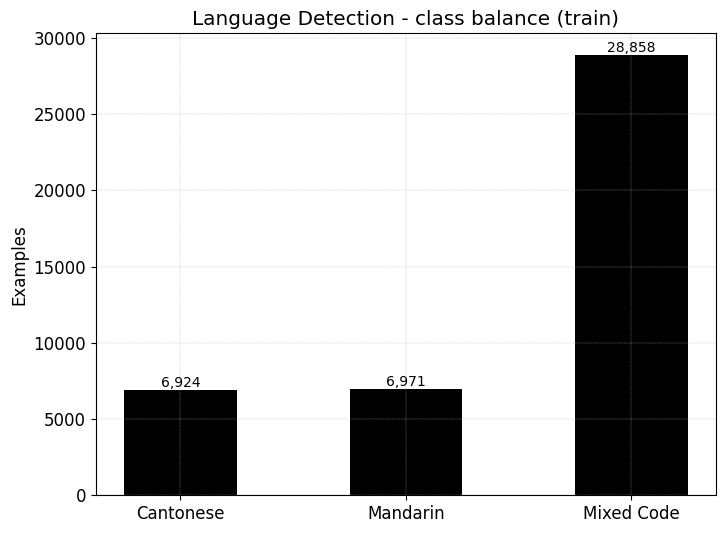

In [42]:
# Create a bar chart
fig, ax = plt.subplots() 
bars = ax.bar(ld_display_labels, ld_counts, color=plot_color[0], width=0.5)
plt.grid(True, linestyle='--', alpha=alpha, linewidth=0.3)
for bar, count in zip(bars, ld_counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            count,
            f'{count:,}',
            ha='center',fontsize = 10, va='bottom')

ax.set_ylabel('Examples')
ax.set_title("Language Detection - class balance (train)")
# save
fig.savefig("../reports/figures/ld_class_balance.png")
plt.show()

### Sentence length stats

In [43]:
ld_lengths = [len(row["sentence"]) for row in lddata_train]

print("Minimum:", min(ld_lengths))
print("Maximum:", max(ld_lengths))
print("Average:", sum(ld_lengths) / len(ld_lengths))
print("Over 100 characters:", sum(1 for length in ld_lengths if length > 100))

Minimum: 5
Maximum: 716
Average: 36.94021472177391
Over 100 characters: 4


### Length distribution plot

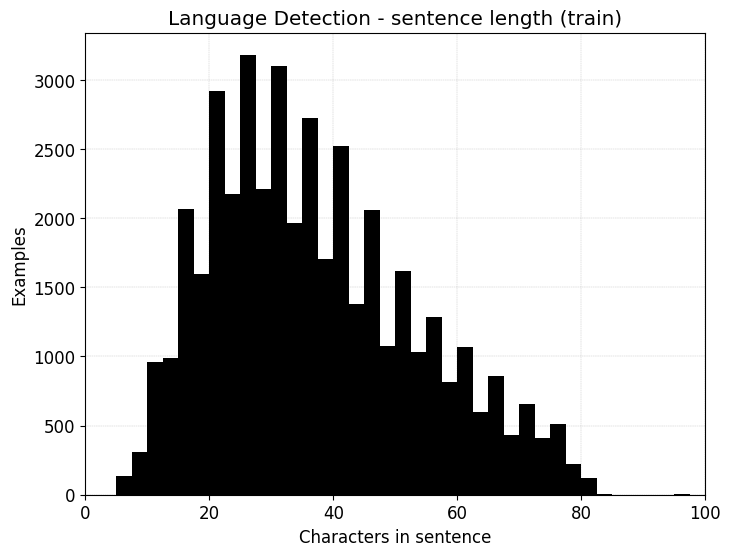

In [44]:
fig, ax = plt.subplots() 
ax.set_xlim(0, 100) # zoom in on the x-axis to focus on the range we are interested in
ax.hist(ld_lengths, bins=40, range=(0, 100), color=plot_color[0])
ax.set_title("Language Detection - sentence length (train)")
ax.set_xlabel("Characters in sentence")
ax.set_ylabel("Examples")
plt.grid(True, linestyle='--', alpha=alpha, linewidth=0.3)
ax.set_axisbelow(True)
fig.savefig("../reports/figures/ld_length.png")
plt.show()

### Data quality checks and cleaning

In [45]:
# check for missing text/label
missing_text = 0
for r in lddata_train:
    if r.get("sentence") is None:
        missing_text += 1

missing_label = 0
for r in lddata_train:
    if r.get("label") is None:
        missing_label += 1

# empty text
empty_text = 0
for r in lddata_train:
    text = r["sentence"].strip()
    if text == "":
        empty_text += 1

ld_found_labels = {r["label"] for r in lddata_train}
ld_text_counts = Counter(r["sentence"] for r in lddata_train)
ld_duplicate_rows = sum(c - 1 for c in ld_text_counts.values() if c > 1)

print(f"Missing text: {missing_text}")
print(f"Missing label: {missing_label}")
print(f"Empty text: {empty_text}")
print(f"Found labels: {ld_found_labels}")
print(f"Duplicate rows: {ld_duplicate_rows}")

Missing text: 0
Missing label: 0
Empty text: 0
Found labels: {0, 1, 2}
Duplicate rows: 268


### Investigating duplicates

In [46]:
by_sentence = {}
for row in lddata_train: by_sentence.setdefault(row["sentence"], []).append(row["label"])

duplicate_sentences = {sentence: labels for sentence, labels in by_sentence.items() if len(labels) > 1}
conflicting_sentences = {sentence: labels for sentence, labels in duplicate_sentences.items() if len(set(labels)) > 1}

print(f"Distinct sentences that appear more than once: {len(duplicate_sentences)}")
print(f"Conflicting labels: {len(conflicting_sentences)}")

for sentence, labels in list(conflicting_sentences.items())[:4]:
    print(f"Sentence: {sentence}, Labels: {labels}")

Distinct sentences that appear more than once: 239
Conflicting labels: 161
Sentence: 大事件前510年代是指前519年至前510年之間的十年。, Labels: [2, 1]
Sentence: 1833年8月英國率先在廣州成立瞭英國駐華司法院，由英國駐華商務總監兼任法官，陪審員委任12位廣州英國僑民擔當，處理當地涉及英僑的各類糾紛。, Labels: [2, 1]
Sentence: 吉安峽江是中國江西吉安的一個縣，總麵積1287平方公裏，人口17.5萬。, Labels: [2, 1]
Sentence: 自然數1442是介於1441和1443之間的自然數。, Labels: [2, 1]


### Findings - Language Detection 

**Class balance.** 
The training set for this data is very imbalanced. 67.5% is 28,858 code mixed examples, 16.2% is 6,924 Cantonese examples, and 16.3% is 6,971 Mandarin examples. 

This imbalance comes from the process that produces up to six corrupted variants for each source pair, while each pair produces only one original of each language. A majority-class classifier would obtain an accuracy of 67.5% without learning anything, so macro-F1 is the appropriate metric for this task.

**Sentence length.**
Overall the sentences are short, the average length is 37 characters. Only 4 sentences are over 100 characters, the longest is 716 characters. The histogram x-axis was zoomed to 100 for readability.

**Data quality.**
No missing text, empty text or missing labels were found. The label set matches the expected set of labels as well {0,1,2}.

**Duplicates.**
268 rows of duplicates were found across 239 unique sentences. Out of these, 161 carry conflicting labels, the same sentence is labeled as both an original language and a corrupted variant. This is because swapping aligned words results in an unchanged string at the lowest corruption rate when the selected words are shared between the two languages. No classifier can label both copies correctly.

**Decision.**
Comparing against published results on Min et al. (2025) on the released splits, removing rows would change the distribution of the dataset and make it different from the published results. Therefore, no rows were removed.

## Sentiment Analysis

### Set up

In [47]:
sentdata_train = load_jsonl("../data/canto-nlu/data/sentiment/train.jsonl")
sentdata_val   = load_jsonl("../data/canto-nlu/data/sentiment/valid.jsonl")
sentdata_test  = load_jsonl("../data/canto-nlu/data/sentiment/test.jsonl")
print(len(sentdata_train), len(sentdata_val), len(sentdata_test))

9999 999 999


### Sample rows

In [48]:
# Print sample rows
print("Sample rows - Sentiment Analysis")
for r in sentdata_train[:3]:
     print(f"[{r['label']}] {r['sentence'][:100]}...")

sent_label_counts = {}
for row in sentdata_train:
    label = row["label"]
    if label in sent_label_counts:
        sent_label_counts[label] += 1
    else:
        sent_label_counts[label] = 1

print("Label counts:", sent_label_counts)
total = sum(sent_label_counts.values())
for label in sorted(sent_label_counts):
    count = sent_label_counts[label]
    print(f"label {label}: {count:,} ({count/total:.1%})")


Sample rows - Sentiment Analysis
[smile] 正宗大板燒 🐿🐿TOP開左都一段日子，餐廳都好幾層！今日就嚟試下千房(^^) 大板燒專門店🤤🤤   千房位於4樓，有bar枱同普通卡位揀！想自己diy就要坐卡位啦！  我地就揀左坐bar枱，師傅燒，唔...
[ok] 唔見得比其他酒家特別好食 一行7人到此酒家食晚飯, 7道海鮮 + 雞連炒飯 & 炒菜共10道菜 total: $2750 無特別好食, 水準只屬合格, 不值專程到流浮山食呢間嘢... ...
[cry] 質素同價錢唔成正比 今日嚟到呢間牛肉麵店食晏，一個人食坐嘅位比較窄，但佢環境都好衛生同埋裝修都唔錯，叫咗碗白胡椒湯牛坑腩幼麵，八護照湯好濃味，好鍾意嗰種刺激嘅感覺，而且牛坑腩嘅份量都算足夠，不過就整得...
Label counts: {'smile': 3333, 'ok': 3333, 'cry': 3333}
label cry: 3,333 (33.3%)
label ok: 3,333 (33.3%)
label smile: 3,333 (33.3%)


### Class distribution plot

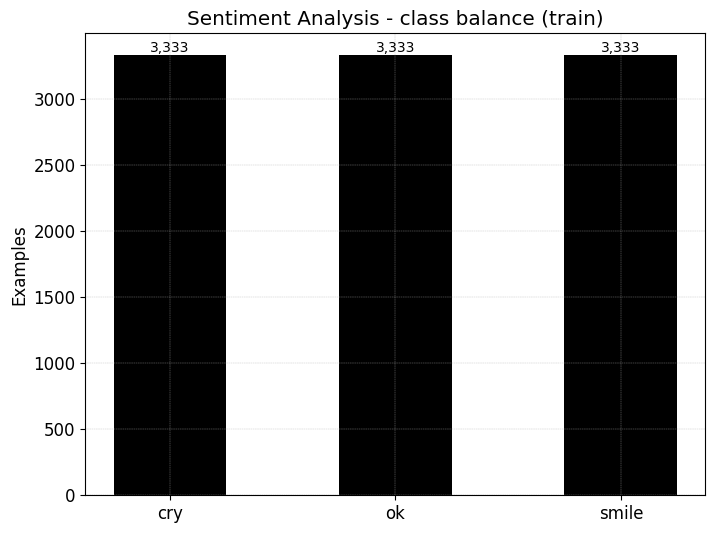

In [49]:
# Create a bar chart for sentiment analysis

sent_labels = sorted(sent_label_counts) # sort list of labels
sent_counts = [sent_label_counts[label] for label in sent_labels]

fig, ax = plt.subplots() 
bars = ax.bar(sent_labels, sent_counts, color=plot_color[0], width=0.5)
plt.grid(True, linestyle='--', alpha=alpha, linewidth=0.3)
for bar, count in zip(bars, sent_counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            count,
            f'{count:,}',
            ha='center',fontsize = 10, va='bottom')

ax.set_ylabel('Examples')
ax.set_title("Sentiment Analysis - class balance (train)")
fig.savefig("../reports/figures/sentiment_class_balance.png")
plt.show()

### Sentence length stats

In [50]:
# Sentence length statistics for sentiment analysis
sent_lengths = [len(row["sentence"]) for row in sentdata_train]

print("Sentence length Statistics")
print("Minimum:", min(sent_lengths))
print("Maximum:", max(sent_lengths))
print("Average:", sum(sent_lengths) / len(sent_lengths))

Sentence length Statistics
Minimum: 40
Maximum: 4720
Average: 343.8532853285329


### Histogram of sentence lengths visualization

p50: 288
p90: 541
p95: 670
p99: 999


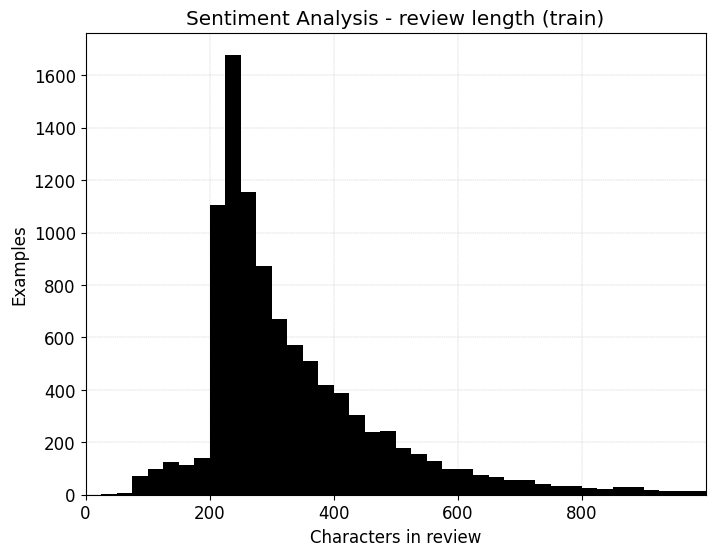

In [51]:
# percentiles to help pick the histogram cap
sorted_lengths = sorted(sent_lengths)
n = len(sorted_lengths)
for p in (50, 90, 95, 99):
    print(f"p{p}: {sorted_lengths[int(n * p / 100)]}")

fig, ax = plt.subplots()
ax.set_xlim(0, 999)
ax.hist(sent_lengths, bins=40, range=(0, 999), color=plot_color[0])
ax.set_title("Sentiment Analysis - review length (train)")
ax.set_xlabel("Characters in review")
ax.set_ylabel("Examples")
plt.grid(True, linestyle='--', alpha=alpha, linewidth=0.3)
ax.set_axisbelow(True)
fig.savefig("../reports/figures/sentiment_length.png")
plt.show()

### Data quality checks and cleaning

In [52]:
# check for missing text/label
sa_missing_text = 0
for r in sentdata_train:
    if r.get("sentence") is None:
        sa_missing_text += 1

sa_missing_label = 0
for r in sentdata_train:
    if r.get("label") is None:
        sa_missing_label += 1

# empty text
sa_empty_text = 0
for r in sentdata_train:
    text = r["sentence"].strip()
    if text == "":
        sa_empty_text += 1

sentdata_found_labels = {r["label"] for r in sentdata_train}
sentdata_text_counts = Counter(r["sentence"] for r in sentdata_train)
sentdata_duplicate_rows = sum(c - 1 for c in sentdata_text_counts.values() if c > 1)

print(f"Missing text: {sa_missing_text}")
print(f"Missing label: {sa_missing_label}")
print(f"Empty text: {sa_empty_text}")
print(f"Found labels: {sentdata_found_labels}")
print(f"Duplicate rows: {sentdata_duplicate_rows}")

Missing text: 0
Missing label: 0
Empty text: 0
Found labels: {'cry', 'smile', 'ok'}
Duplicate rows: 0


### Findings - Sentiment Analysis 

**Class balance.** 
Each class has 3,333 examples per class, the dataset is balanced. Accuracy and macro-F1 behave similarly and a
majority-class baseline sits at 33.3%.

**Sentence length.**
These are much longer than the language detection dataset sentences, the median is 288, the mean is 344 and the maximum is 4,720. The histogram is limited to 999 characters for readability.

**Data quality.**
No missing text, empty text or missing labels were found. The label set matches the expected set of labels as well {smile, ok, cry}.

### Summary of findings

These two datasets are very different in terms of sentence length and class balance. 

Language Detection is synthetic, constructed by perturbing a parallel corpus, and carries the artifacts of that process: a 4:1 imbalance by design and 161 examples that carry conflicting labels. 

Sentiment Analysis is naturally scraped text and is cleaner by comparison. It is perfectly balanced, no duplicates, and no missing values. Neither of the datasets needed cleaning. Both datasets have been kept as released to maintain the comparability of the results to the published baselines. 
